In [1]:
pip install -U pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.4 MB/s eta 0:00:00


Final Objective Values:
[[-5509.72287705   535.86582376]
 [-4605.3340412    308.61402956]
 [-4723.2626653    317.62601139]
 ...
 [-4896.45151453   330.43812405]
 [-4709.05335978   316.10020131]
 [-5438.26108391   431.48803966]]

Final Decision Variables:
[[2.50000018 2.54371428 2.76151716 ... 2.90646377 2.69852695 2.50000168]
 [2.68727578 2.68728251 2.88738762 ... 2.68760374 2.68747033 2.88645085]
 [2.68727763 2.68728275 2.80483012 ... 2.68762007 2.68750245 2.8863671 ]
 ...
 [2.68726889 2.68726924 2.68729476 ... 2.6875992  2.6875354  2.88634816]
 [2.68726896 2.68727163 2.80087203 ... 2.68759665 2.68746913 2.88637604]
 [2.50000153 2.50001141 2.71671263 ... 2.68658847 2.5000039  2.50426062]]

Best Solution:
Objective Values (Weighted Milk Production, Weighted Conception DIM):
[-5440.29139012   432.52084322]
Decision Variables:
[2.50000001 2.50030138 2.71812366 2.50256712 2.6674929  2.92647576
 3.17247394 2.91947512 2.68658725 2.50148456 2.5000241 ]

Worst Solution:
Objective Values (Weig

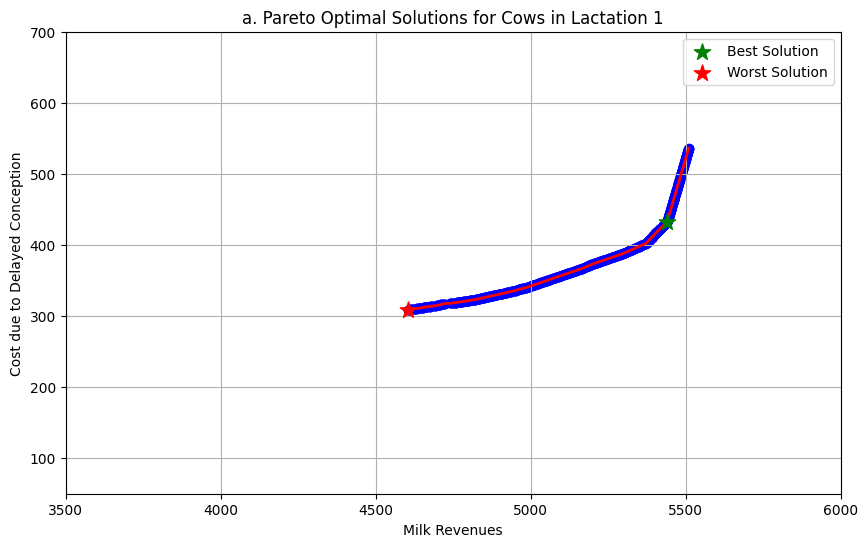

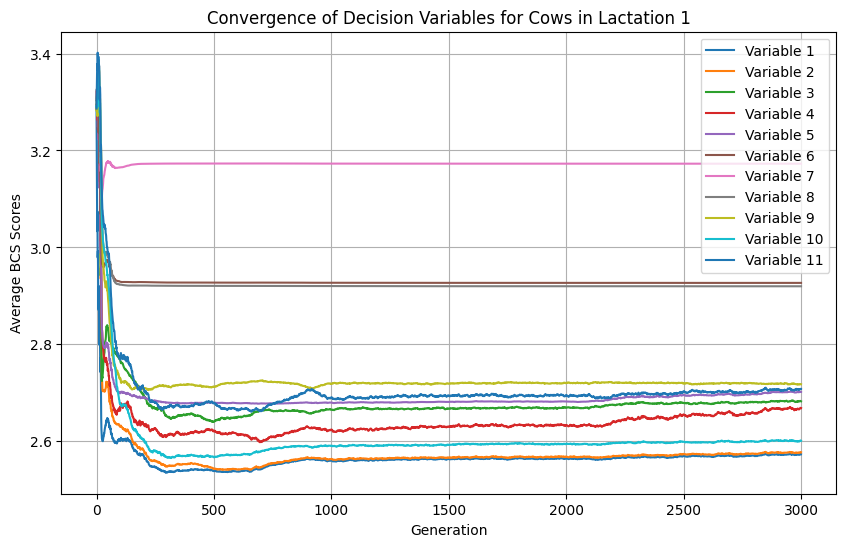

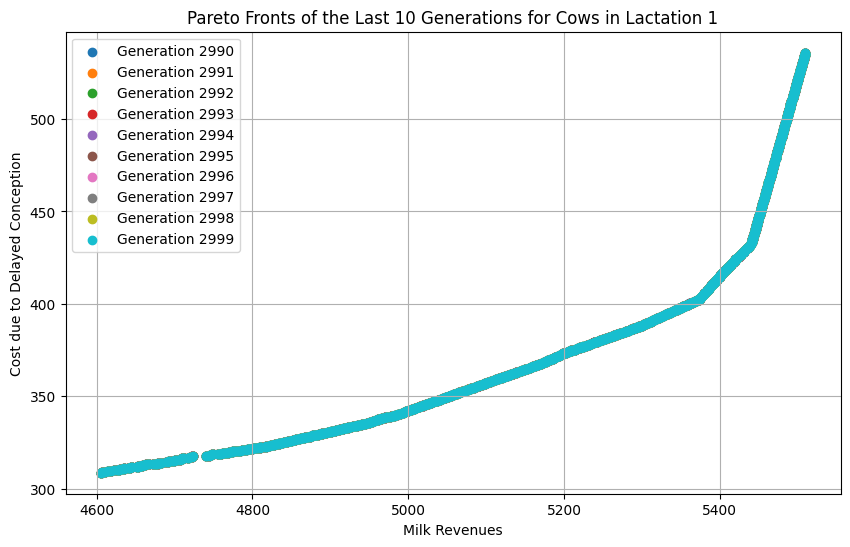

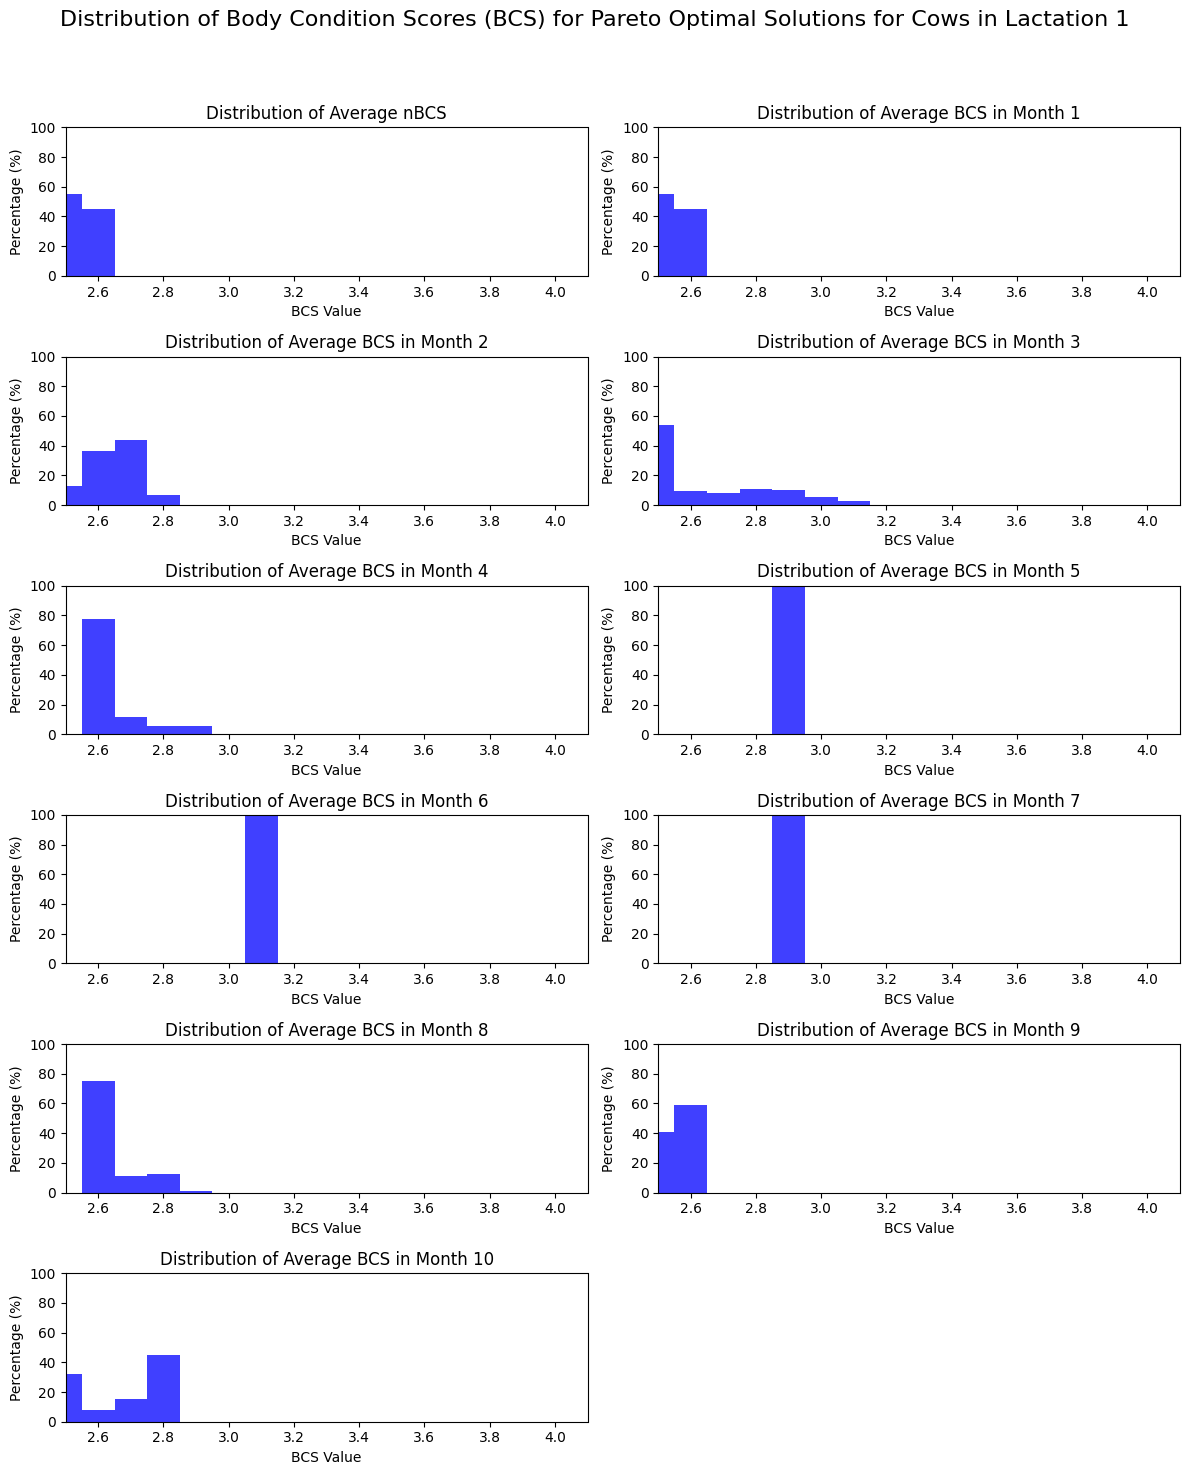

In [2]:
# Lactation1
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0

            # Existing penalty checks
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.218:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.259:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.165:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.259:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.246:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.253:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.233:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.208:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.199:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i].
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (23167 - 137 * x[0] - 449 * x[1] + 853 * x[2]
                               - 2288 * x[3] - 1214 * x[4] - 930 * x[5]
                               + 2048 * x[6] - 1733 * x[7] + 431 * x[8]
                               + 311 * x[9] - 843 * x[10])

            conception_DIM = (158.10 - 78.54 * x[0] + 44.574 * x[1] + 14.586 * x[2]
                  - 30.60 * x[3] + 0.1938 * x[4] + 14.892 * x[5]
                  - 26.214 * x[6] - 24.276 * x[7] + 60.69 * x[8]
                  + 49.062 * x[9] - 35.394 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])


# Weights for 10 months
weights_conception_DIM = [1.39, 3.34, 4.73, 4.47, 4.04, 3.62, 3.17, 2.67, 2.21, 1.72]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:

    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

# Initialize callback
callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),  # Increased number of generations
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print()

print("Final Decision Variables:")
print(res.X)
print()

# Find the best solution from the last generation
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]

# Change weighted milk production to positive and subtract weighted conception DIM
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]

print("Best Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(best_solution)
print("Decision Variables:")
print(best_decision_vars)
print()

# Find the worst solution from the last generation
worst_index = np.argmin(objective_values)
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("Worst Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(worst_solution)
print("Decision Variables:")
print(worst_decision_vars)
print()

# Plot Pareto front with line, highlighting best and worst solutions
plt.figure(figsize=(10, 6))

# Plot all Pareto front solutions with a red line
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)  # Changed sign for plotting

# Plot all solutions in blue
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')  # Changed sign for plotting

# Highlight the best solution with a green star (plotted after the blue points)
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)

# Highlight the worst solution with a red star (plotted after the blue points)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)

# Set axis limits
plt.xlim(3500, 6000)
plt.ylim(50, 700)

plt.title('a. Pareto Optimal Solutions for Cows in Lactation 1')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot convergence of decision variables
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])

plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 1')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Pareto fronts of the last 10 generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 1')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram of Pareto optimal solutions with percentage on y-axis
pareto_solutions = res.X  # These are the decision variables of the Pareto front solutions
n_vars = problem.n_var

# Define the bin size
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)  # Set bins from 2.5 to 4.1 with 0.1 intervals

# Plot histograms of Pareto optimal solutions for each decision variable
plt.figure(figsize=(12, 15))

for i in range(n_vars):
    plt.subplot(6, 2, i + 1)  # Create subplots in a 5x2 grid

    # Create histogram data
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)

    # Convert to percentage by multiplying by 100
    percentages = counts * np.diff(bins)[0] * 100

    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')

    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    if i == 0:
        plt.title("Distribution of Average nBCS")
    else:
        plt.title(f"Distribution of Average BCS in Month {i}")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')

plt.suptitle(
    'Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 1',
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-5018.42809376   295.67445408]
 [-5908.23866349   502.02371857]
 [-5894.34397307   485.34860126]
 ...
 [-5641.09821388   370.68118772]
 [-5609.06817869   363.58884381]
 [-5536.4121401    350.49132182]]

Final Decision Variables:
[[2.65187196 2.65187707 2.65191074 ... 2.87697071 2.6529781  2.87397166]
 [2.50000191 2.55903996 2.81899788 ... 2.75039478 2.93070068 2.71126571]
 [2.50000118 2.55906211 2.81899886 ... 2.74966971 2.83646218 2.6362672 ]
 ...
 [2.50002003 2.50043072 2.75860331 ... 2.72431109 2.50033033 2.66119487]
 [2.50003248 2.50050984 2.76002949 ... 2.72407159 2.50017034 2.72034946]
 [2.50019888 2.50053075 2.75865017 ... 2.723885   2.50047582 2.72073353]]

Best Solution:
Objective Values: [-5892.36371004   466.16933898]
Decision Variables: [2.50001409 2.55905831 2.81901476 2.51108349 2.50001977 2.76430506
 2.51231967 2.50026142 2.75023113 2.72087865 2.50004855]

Worst Solution:
Objective Values: [-5018.42809376   295.67445408]
Decision Variables: [2.6

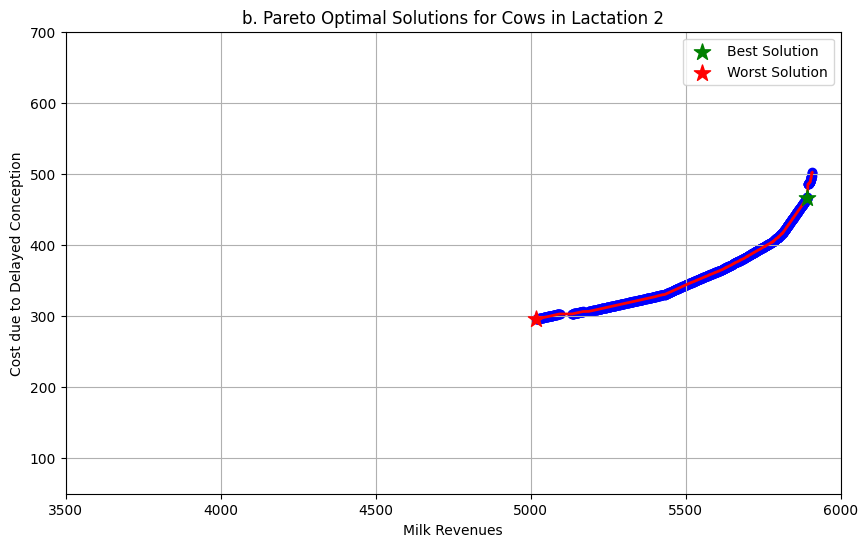

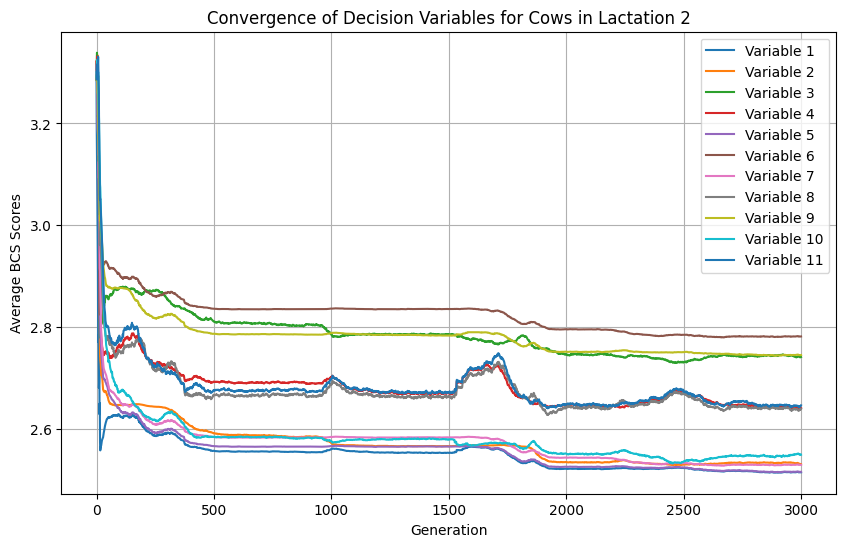

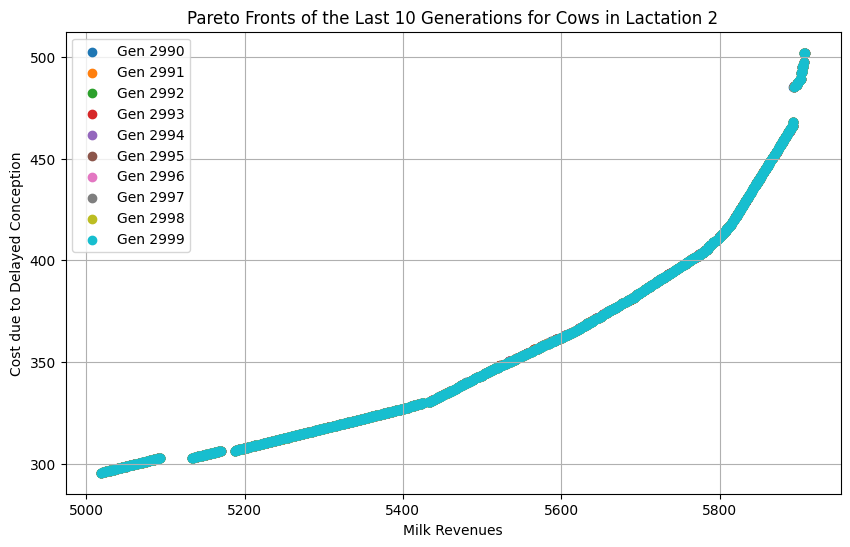

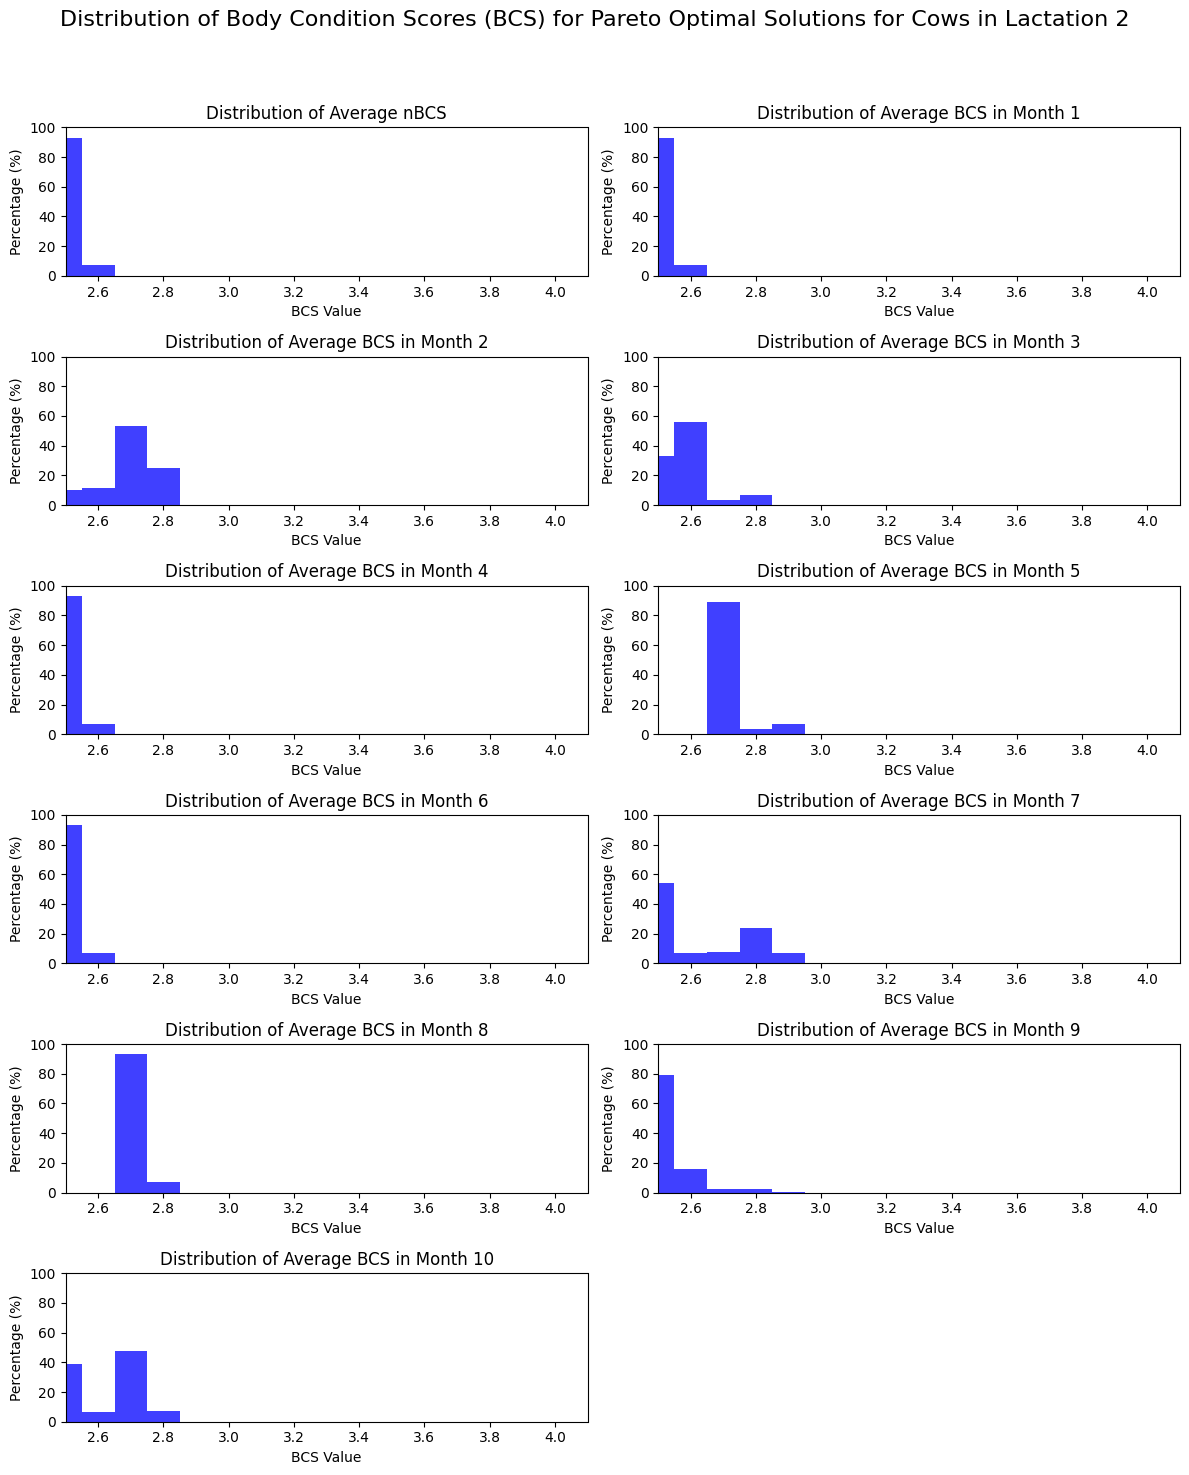

In [3]:
# Lactation 2
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.260:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.308:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.183:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.270:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.252:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.272:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.250:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.224:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.221:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (21344 - 563 * x[0] - 1135 * x[1] + 2097 * x[2]
                               - 1213 * x[3] - 1431 * x[4] + 1073 * x[5]
                               - 924 * x[6] - 1671 * x[7] + 447 * x[8]
                               + 1018 * x[9] - 822 * x[10])

            conception_DIM = (147.90 - 63.444 * x[0] + 11.73 * x[1] + 15.81 * x[2]
                  - 25.704 * x[3] + 26.418 * x[4] - 40.29 * x[5]
                  + 48.756 * x[6] - 25.806 * x[7] - 1.1832 * x[8]
                  + 53.652 * x[9] - 15.708 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.40, 4.00, 5.13, 4.73, 4.23, 3.77, 3.27, 2.70, 2.20, 1.67]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6000)
plt.ylim(50, 700)
plt.title('b. Pareto Optimal Solutions for Cows in Lactation 2')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 2')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Gen {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 2')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 2', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4614.94127344   265.00198095]
 [-5879.50676033   673.20073527]
 [-5015.43379156   330.3421719 ]
 ...
 [-5877.04193316   660.98131084]
 [-5312.30557829   374.31223439]
 [-5465.02368038   401.08179507]]

Final Decision Variables:
[[2.93123117 2.9316893  2.93127852 ... 2.932675   2.93173552 3.19560744]
 [2.5        2.56901309 2.87494847 ... 2.75682641 2.93588299 2.67188484]
 [2.75333325 2.75343485 2.75335833 ... 2.75352301 2.7536988  3.01752726]
 ...
 [2.5000002  2.56901544 2.8749617  ... 2.75674668 2.9358802  2.67189174]
 [2.50000001 2.50000209 2.50001718 ... 2.50000412 2.50012756 2.76374126]
 [2.50000006 2.50000603 2.50000355 ... 2.50000439 2.50007392 2.68724143]]

Best Solution:
Objective Values: [-5836.36661667   580.49793175]
Decision Variables: [2.50000001 2.56906127 2.87481161 2.50000641 2.50000033 2.50370152
 2.5000004  2.50000274 2.50415969 2.76389421 2.50000068]

Worst Solution:
Objective Values: [-4614.94127344   265.00198095]
Decision Variables: [2.9

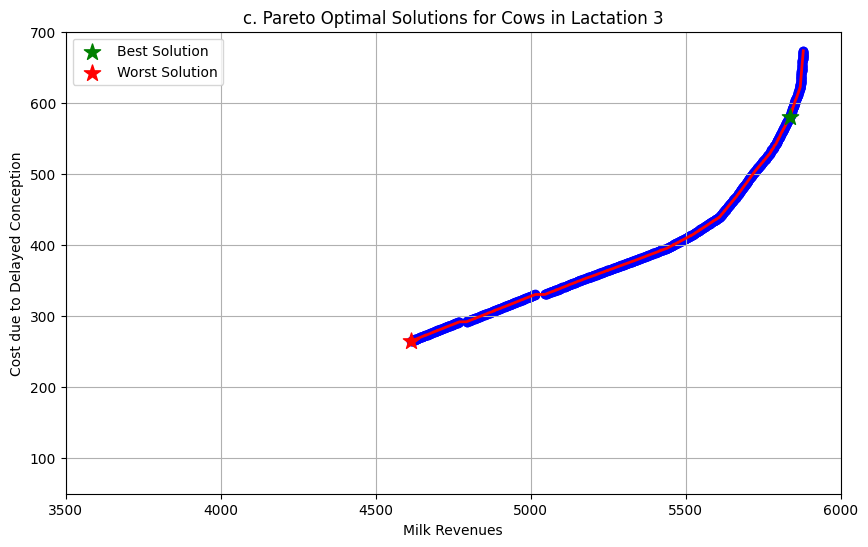

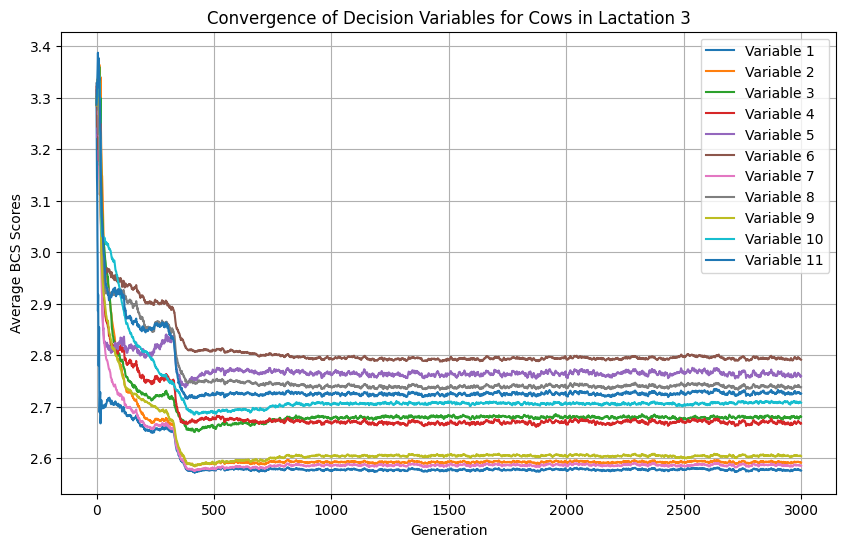

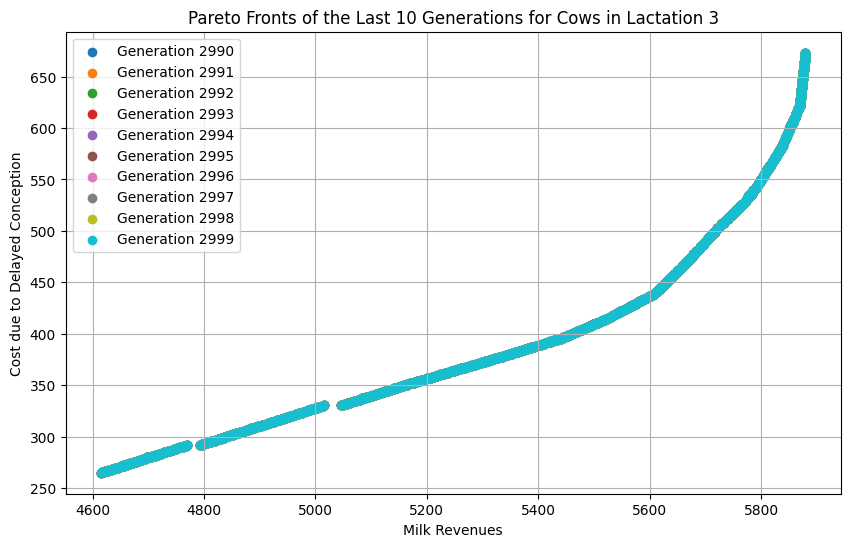

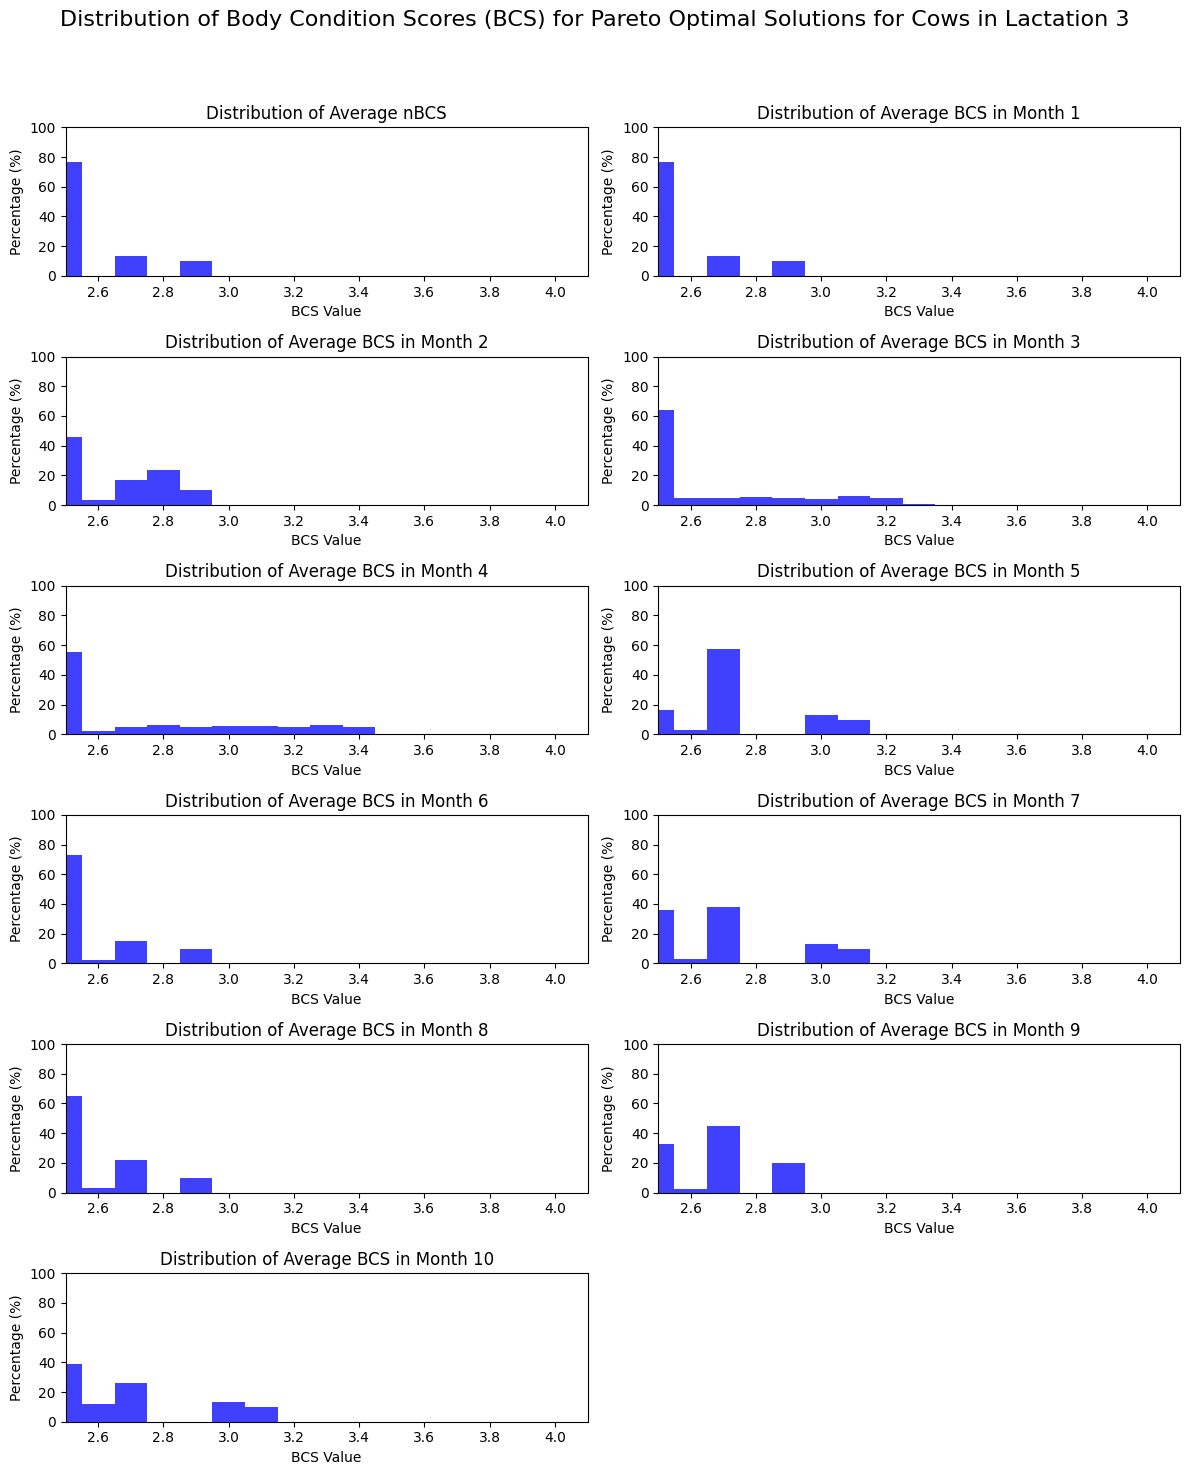

In [4]:
# Lactation 3
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.306:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.375:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.246:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.293:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.260:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.277:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.257:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.260:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.264:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20295 - 519 * x[0] - 168 * x[1] + 867 * x[2] - 1074 * x[3]
                               -1063 * x[4] - 439 * x[5] + 94.7 * x[6] - 534 * x[7] + 282 * x[8]
                               + 829 * x[9] - 770 * x[10])

            conception_DIM = (185.64 - 73.848 * x[0] + 2.448 * x[1] + 40.392 * x[2] - 12.954 * x[3]
                  - 13.872 * x[4] - 33.252 * x[5] + 48.348 * x[6] - 22.236 * x[7]
                  + 32.946 * x[8] + 18.564 * x[9] - 13.974 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.00, 4.13, 5.53, 5.10, 4.50, 3.90, 3.27, 2.60, 1.87, 1.10]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6000)
plt.ylim(50, 700)
plt.title('c. Pareto Optimal Solutions for Cows in Lactation 3')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 3')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 3')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 3', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-5980.03689304   657.17657192]
 [-4372.71697402    99.98167794]
 [-4995.30503299   179.37352717]
 ...
 [-5229.42418124   239.39305092]
 [-5259.18731501   247.88288524]
 [-5638.49676597   371.86764573]]

Final Decision Variables:
[[2.50000001 3.37191375 3.09697856 ... 2.79600238 2.54517833 2.50001926]
 [3.10206835 3.10236136 3.36819106 ... 3.10220434 3.33043238 3.10230339]
 [2.50000004 2.50000521 2.77574277 ... 2.5000054  2.72676716 2.50000121]
 ...
 [2.5        2.50001379 2.77260545 ... 2.50000867 2.53661186 2.50000357]
 [2.50000009 2.50010249 2.77600239 ... 2.50894561 2.55650083 2.50000397]
 [2.50000005 2.50003999 2.77584696 ... 2.6395043  2.50027686 2.50002025]]

Best Solution:
Objective Values: [-5898.51972569   509.89490555]
Decision Variables: [2.50000033 2.82284988 3.09693922 2.71898392 2.50000076 2.77099087
 2.50000523 2.50003093 2.79600192 2.54533781 2.50000044]

Worst Solution:
Objective Values: [-4372.71697402    99.98167794]
Decision Variables: [3.1

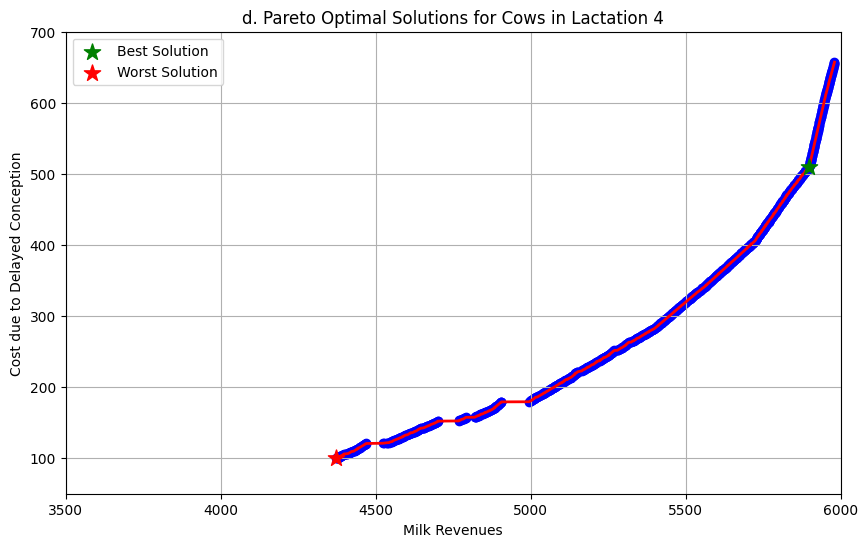

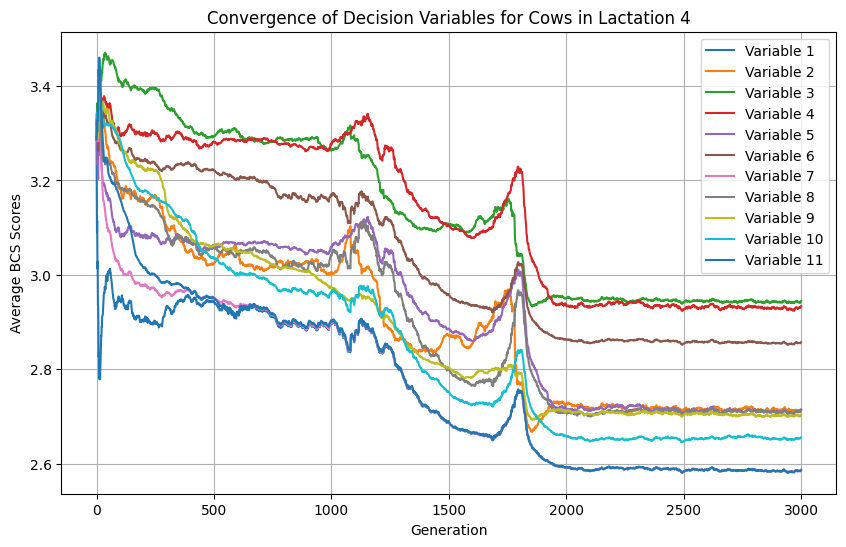

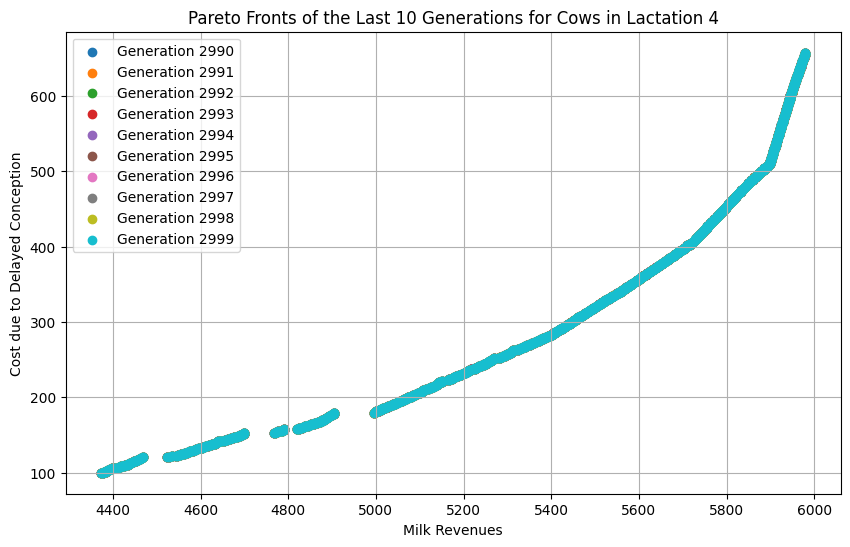

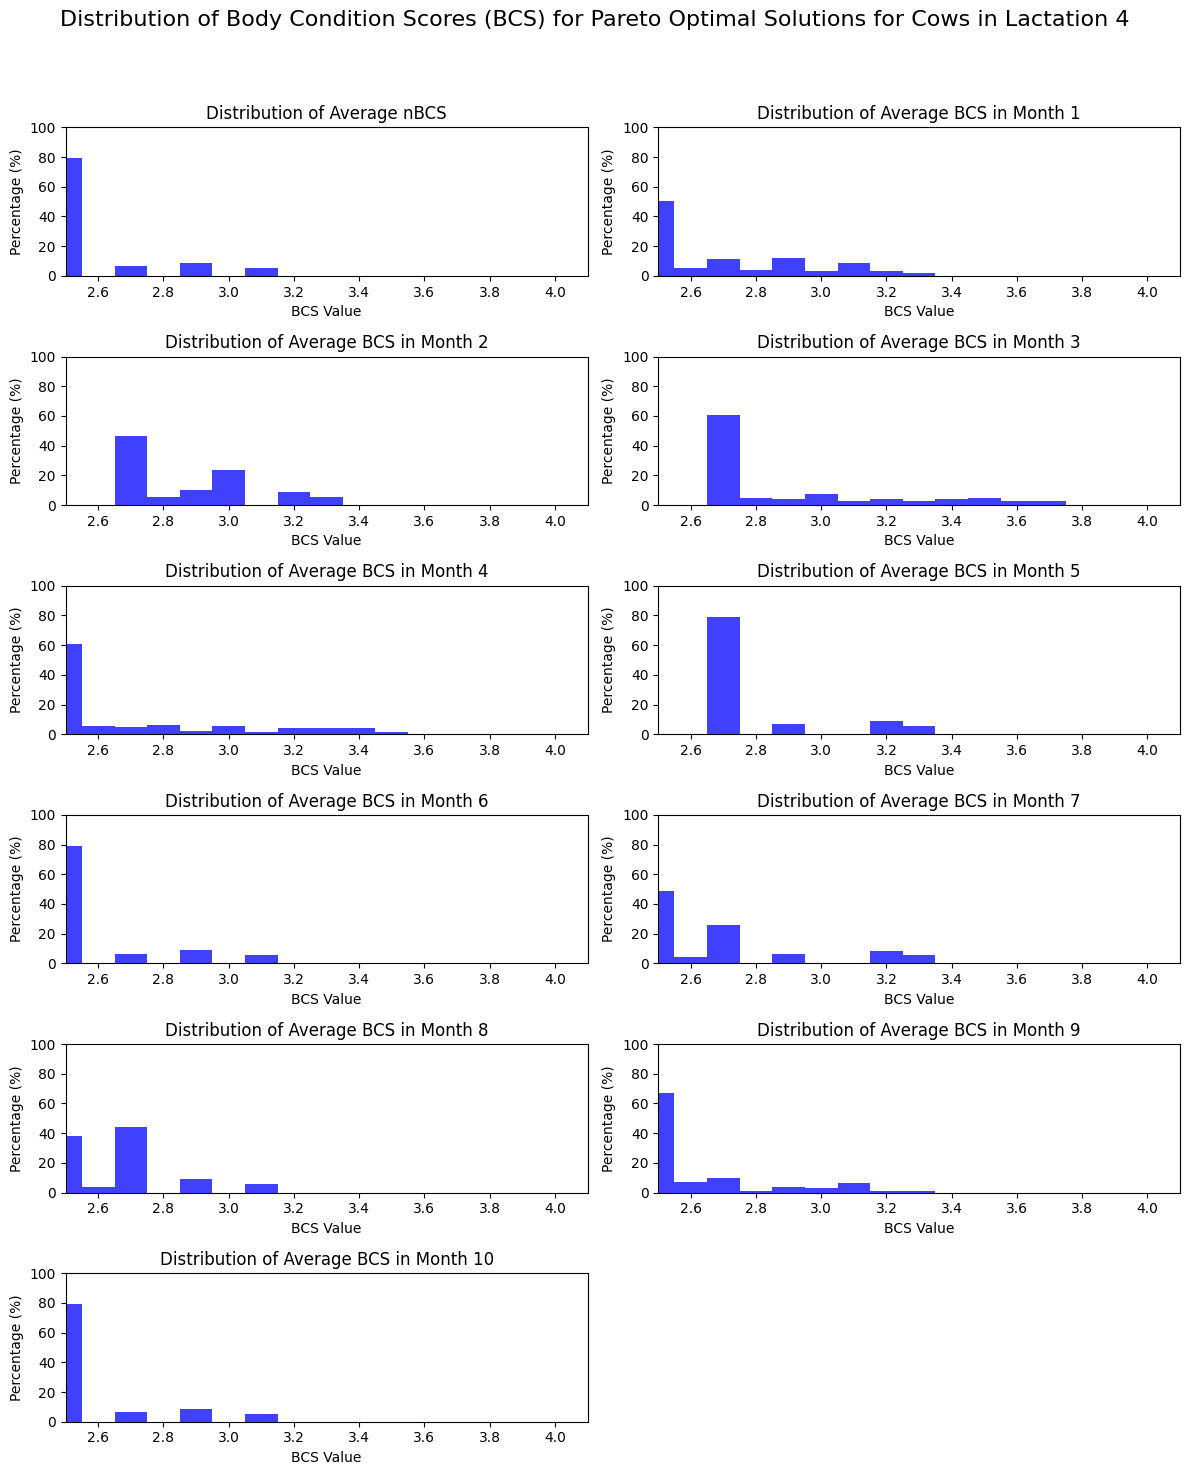

In [5]:
# Lactation 4
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.276:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.378:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.219:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.274:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.271:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.259:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.296:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.251:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.233:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20094 - 732 * x[0] + 371 * x[1] + 986 * x[2] + 313 * x[3]
                               - 2613 * x[4] + 4.19 * x[5] - 558 * x[6] - 1553 * x[7]
                               + 1381 * x[8] - 64.8 * x[9] - 147 * x[10])

            conception_DIM = (197.88 - 95.574 * x[0] + 64.26 * x[1] + 3.1926 * x[2] - 60.282 * x[3]
                  + 16.626 * x[4] - 37.944 * x[5] + 70.482 * x[6] - 42.84 * x[7]
                  + 43.962 * x[8] - 1.4178 * x[9] + 6.273 * x[10])

            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [1.73, 3.93, 5.37, 4.97, 4.37, 3.80, 3.17, 2.47, 1.77, 0.93]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6000)
plt.ylim(50, 700)
plt.title('d. Pareto Optimal Solutions for Cows in Lactation 4')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 4')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 4')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 4', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4122.13631536   283.13629972]
 [-5812.65247572   556.27445609]
 [-4221.40809631   293.18866155]
 ...
 [-5750.23514861   528.74434354]
 [-5804.0700879    553.11415176]
 [-5471.72153262   441.44135138]]

Final Decision Variables:
[[3.09752806 3.09780658 3.09753404 ... 3.10686561 3.10980933 3.33576613]
 [2.5000006  2.59685073 2.86241472 ... 2.94309672 3.17370182 2.94883396]
 [3.09752827 3.09780629 3.23618262 ... 3.10213296 3.10979637 3.33577133]
 ...
 [2.50000064 2.58687862 2.8519726  ... 2.78087266 3.01270298 2.89209013]
 [2.50000071 2.59671294 2.86241639 ... 2.94309672 3.17284002 2.98793062]
 [2.50000021 2.50004134 2.76598332 ... 2.77512777 3.00510471 3.23071552]]

Best Solution:
Objective Values (Weighted Milk Production, Weighted Conception DIM):
[-5812.65247572   556.27445609]
Decision Variables:
[2.5000006  2.59685073 2.86241472 2.54151491 2.50010085 2.77376972
 2.95381047 2.69120427 2.94309672 3.17370182 2.94883396]

Worst Solution:
Objective Values (Weig

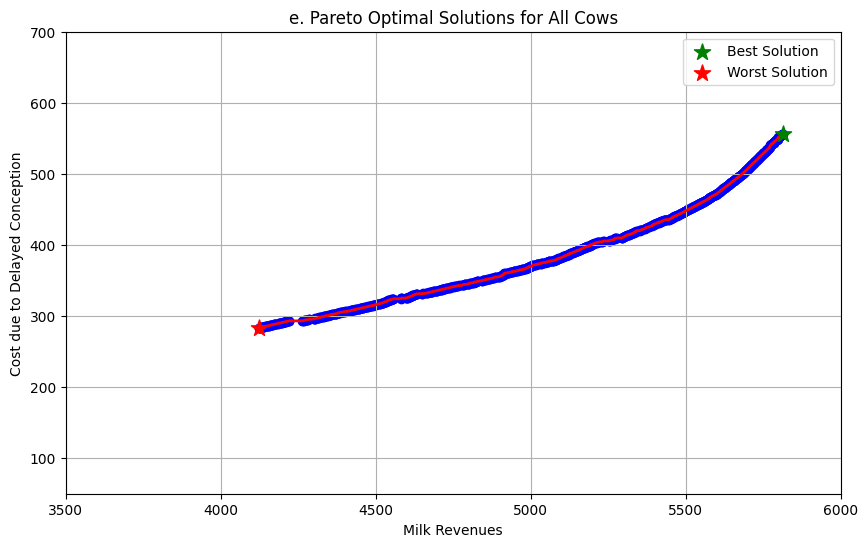

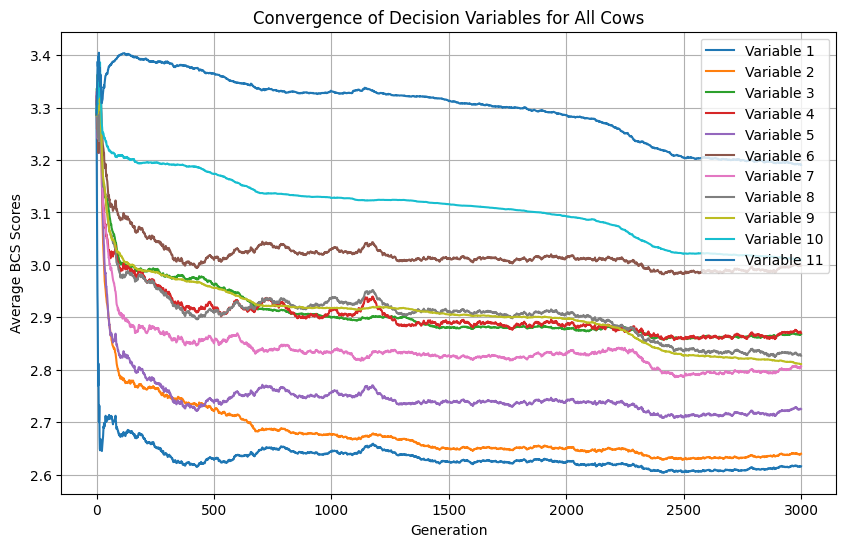

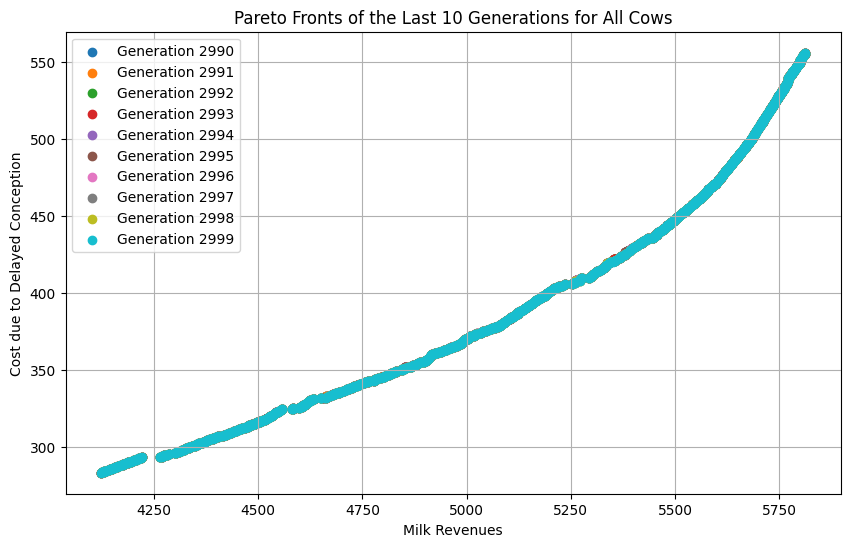

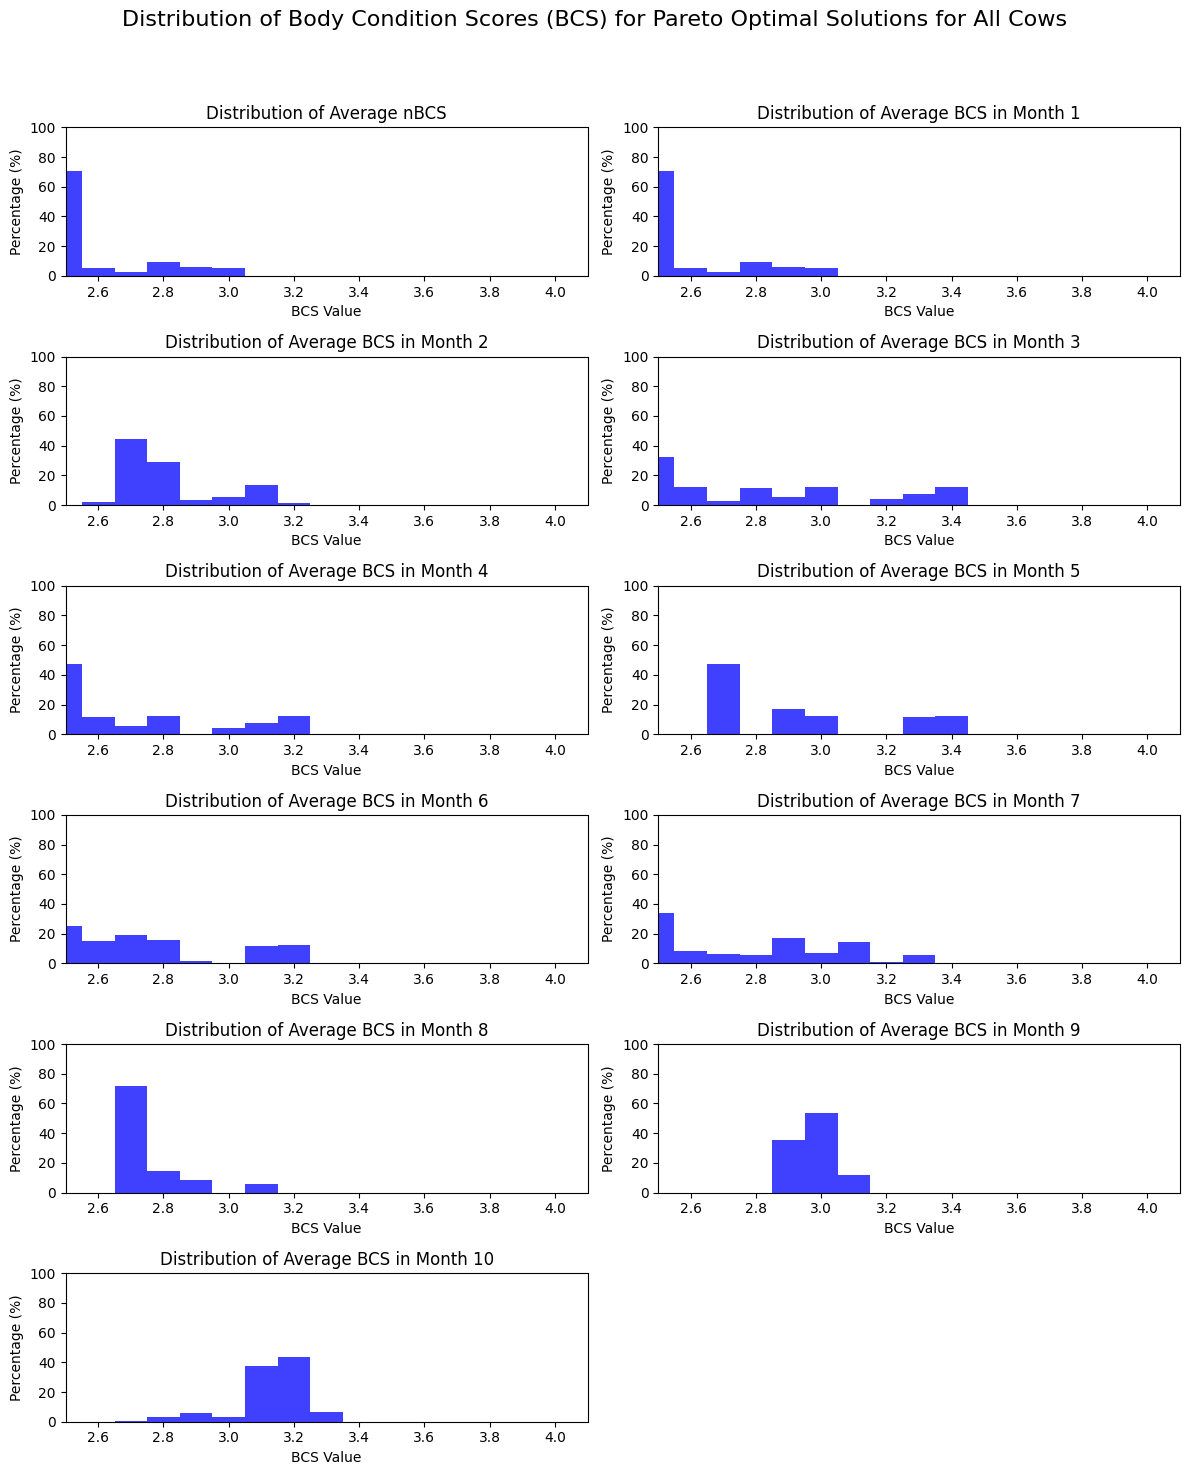

In [6]:
#All Cows
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0

            # Existing penalty checks
            # (Though you've put these in a for-loop over i in range(9),
            #  notice you are not using 'i' here, so the same set of checks
            #  effectively runs 9 times. You can keep or remove that loop
            #  depending on your intent. Below is kept as-is.)
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.266:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.321:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.201:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.274:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.254:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.266:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.252:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.232:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.226:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i].
            # Penalize any violation where x[0] > x[i].
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            # Your objective calculations
            milk_production = (20514 - 2192 * x[0] - 383 * x[1]
                               + 1760 * x[2] - 1204 * x[3]
                               - 1919 * x[4] + 283 * x[5]
                               + 740 * x[6] - 1499 * x[7]
                               + 819 * x[8] + 1080 * x[9]
                               - 496 * x[10])

            conception_DIM = (185.64 - 40.494 * x[0] + 17.85 * x[1]
                  + 16.014 * x[2] - 27.132 * x[3]
                  + 12.444 * x[4] - 32.436 * x[5]
                  + 24.888 * x[6] - 24.582 * x[7]
                  + 23.766 * x[8] + 28.458 * x[9]
                  - 20.91 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [1.39, 3.34, 4.73, 4.47, 4.04, 3.62, 3.17, 2.67, 2.21, 1.72]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:

    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

# Initialize callback
callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),  # Increased number of generations
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print()

print("Final Decision Variables:")
print(res.X)
print()

# Find the best solution from the last generation
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]

# Change weighted milk production to positive and subtract weighted conception DIM
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]

print("Best Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(best_solution)
print("Decision Variables:")
print(best_decision_vars)
print()

# Find the worst solution from the last generation
worst_index = np.argmin(objective_values)
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("Worst Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(worst_solution)
print("Decision Variables:")
print(worst_decision_vars)
print()

# Plot Pareto front with line, highlighting best and worst solutions
plt.figure(figsize=(10, 6))

# Plot all Pareto front solutions with a red line
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)  # Changed sign for plotting

# Plot all solutions in blue
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')  # Changed sign for plotting

# Highlight the best solution with a green star
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)

# Highlight the worst solution with a red star
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)

# Set axis limits
plt.xlim(3500, 6000)
plt.ylim(50, 700)

plt.title('e. Pareto Optimal Solutions for All Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot convergence of decision variables
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])

plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for All Cows')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Pareto fronts of the last 10 generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for All Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram of Pareto optimal solutions with percentage on y-axis
pareto_solutions = res.X  # These are the decision variables of the Pareto front solutions
n_vars = problem.n_var

# Define the bin size
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)  # Set bins from 2.5 to 4.1 with 0.1 intervals

# Plot histograms of Pareto optimal solutions for each decision variable
plt.figure(figsize=(12, 15))

for i in range(n_vars):
    plt.subplot(6, 2, i + 1)

    # Create histogram data
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)

    # Convert to percentage
    percentages = counts * np.diff(bins)[0] * 100

    # Plot the histogram using percentage on y-axis
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')

    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    if i == 0:
        plt.title("Distribution of Average nBCS")
    else:
        plt.title(f"Distribution of Average BCS in Month {i}")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')

plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for All Cows', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4496.90756605   252.97608192]
 [-5855.21538178   522.12712269]
 [-5072.85415172   318.02776556]
 ...
 [-5792.41708024   481.80692235]
 [-5218.98604342   331.10061399]
 [-5679.3681101    435.93475844]]

Final Decision Variables:
[[2.99670091 2.99672727 2.99692139 ... 2.99719586 2.9967026  3.22879089]
 [2.50001191 2.6570767  2.93881852 ... 2.75503454 2.86357134 2.6290504 ]
 [2.65704232 2.65718049 2.72713133 ... 2.65783502 2.65706621 2.82483846]
 ...
 [2.50000077 2.50328551 2.78500767 ... 2.7480271  2.66232736 2.50031465]
 [2.50514964 2.50520914 2.56777814 ... 2.50580764 2.50525861 2.73740543]
 [2.50000107 2.50353059 2.78521915 ... 2.52404455 2.50203055 2.50066699]]

Best Solution:
Objective Values: [-5838.30538856   500.58360869]
Decision Variables: [2.50000284 2.54265759 2.82444115 2.5000968  2.50021346 2.76324779
 2.50528891 2.50007878 2.75690704 2.73501396 2.50003395]

Worst Solution:
Objective Values: [-4496.90756605   252.97608192]
Decision Variables: [2.9

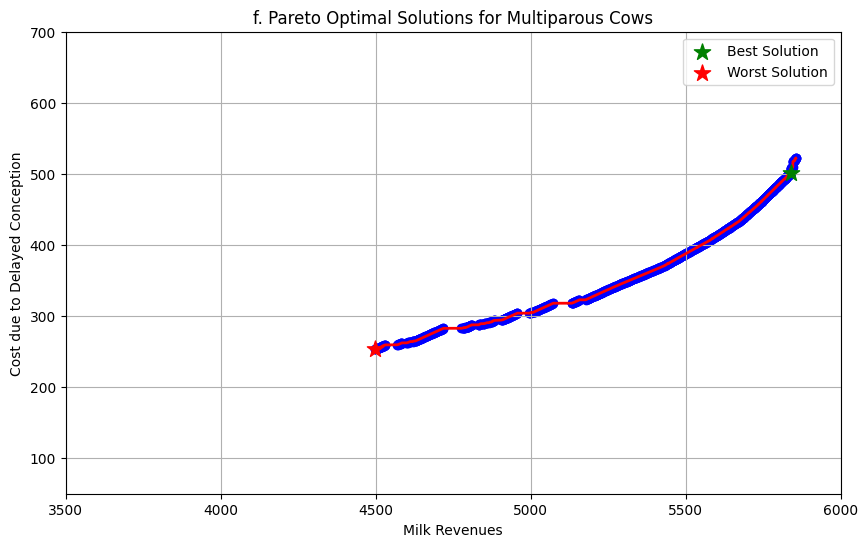

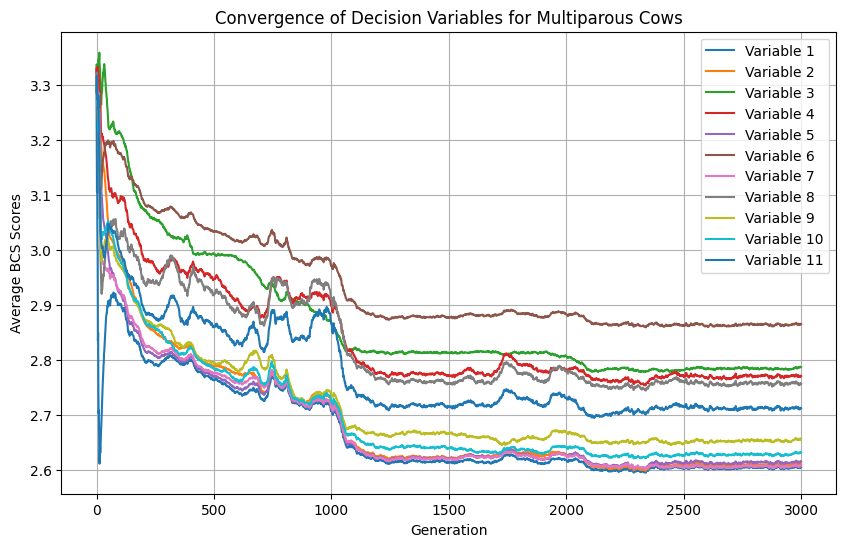

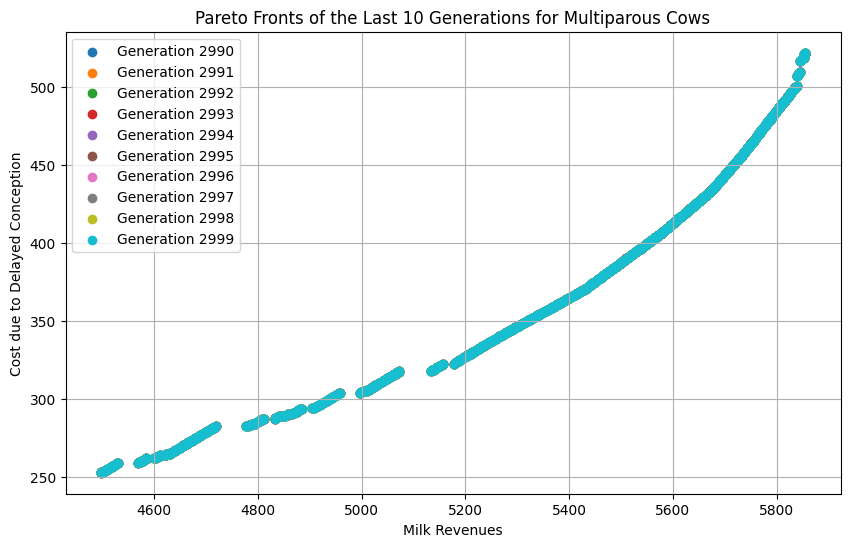

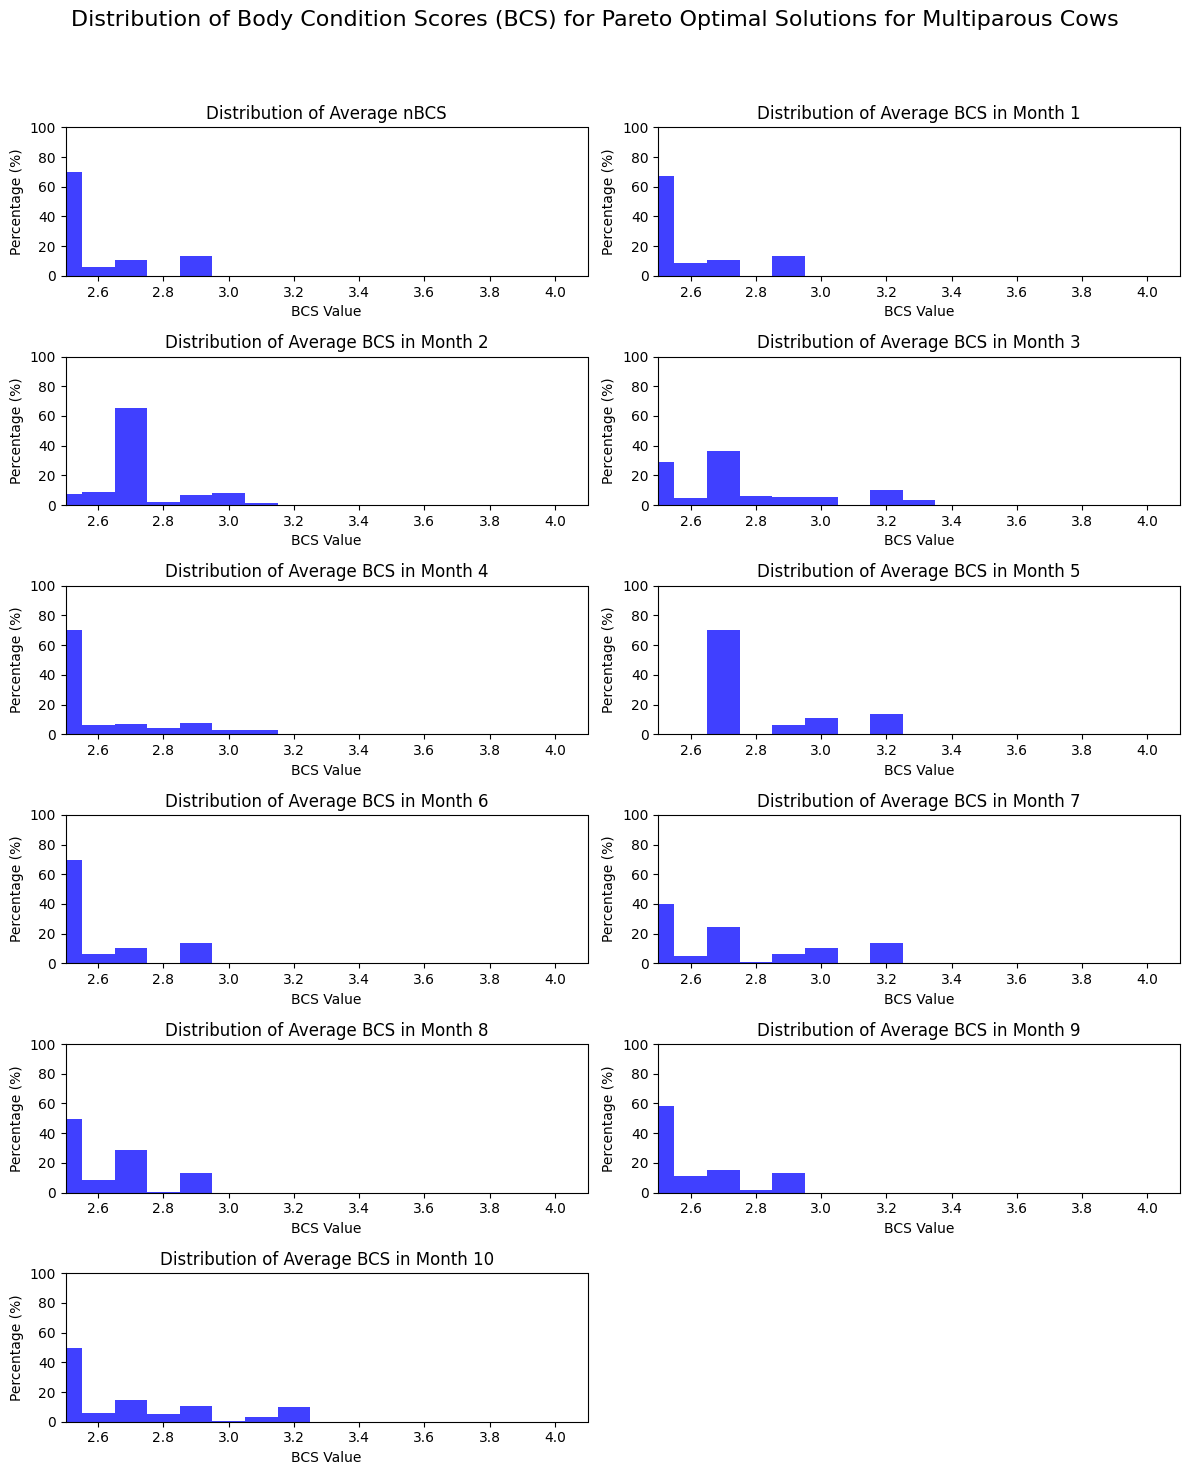

In [7]:
# Multiparous
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.282:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.346:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.217:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.279:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.258:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.272:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.257:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.237:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.235:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20662 - 665 * x[0] - 573 * x[1] + 1651 * x[2] - 1116 * x[3]
                               - 1470 * x[4] + 103 * x[5] - 159 * x[6] - 1355 * x[7]
                               + 607 * x[8] + 908 * x[9] - 720 * x[10])

            conception_DIM = (167.28 - 72.828 * x[0] + 16.116 * x[1] + 24.378 * x[2] - 25.602 * x[3]
                  + 7.9356 * x[4] - 41.31 * x[5] + 56.406 * x[6] - 26.826 * x[7]
                  + 18.87 * x[8] + 31.62 * x[9] - 10.812 * x[10])

            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.04, 4.02, 5.34, 4.93, 4.37, 3.82, 3.23, 2.59, 1.94, 1.23]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worse_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worse_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6000)
plt.ylim(50, 700)
plt.title('f. Pareto Optimal Solutions for Multiparous Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Multiparous Cows')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Multiparous Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Multiparous Cows', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()